In [1]:
import pandas as pd
import numpy as np
import joblib


df = pd.read_parquet('../data/processed/features.parquet')


model = joblib.load('../models/best_hgb_pipeline.pkl')

print(f"Loaded dataset: {df.shape}")
print("Loaded model pipeline.")

Loaded dataset: (514983, 56)
Loaded model pipeline.


In [3]:
import shap

In [8]:
exclude_cols = [
    'bankname', 'approvaldate', 'loanstatus', 'grosschargeoffamount', 
    'target', 'approvalfy', 'bankstate', 'borrstate', 'naicscode', 
    'businessage',                  
    'fixedorvariableinterestind',   
    'franchisecode',                
    'bank_prior_defaults',          
    'bank_prior_loans',             
    'sector_historical_default_rate',  
]
feature_cols = [c for c in df.columns if c not in exclude_cols]


In [9]:
print(feature_cols)
print(len(feature_cols))

['asofdate', 'program', 'locationid', 'borrname', 'borrstreet', 'borrcity', 'borrzip', 'bankfdicnumber', 'bankncuanumber', 'bankstreet', 'bankcity', 'bankzip', 'grossapproval', 'sbaguaranteedapproval', 'firstdisbursementdate', 'processingmethod', 'subprogram', 'initialinterestrate', 'terminmonths', 'naicsdescription', 'franchisename', 'projectcounty', 'projectstate', 'sbadistrictoffice', 'congressionaldistrict', 'businesstype', 'paidinfulldate', 'chargeoffdate', 'revolverstatus', 'jobssupported', 'collateralind', 'soldsecmrktind', 'naics_sector', 'business_age_group', 'is_variable_rate', 'is_franchise', 'bank_prior_def_rate', 'is_same_state_bank', 'bank_experience_tier', 'unguaranteed_exposure', 'log_gross_approval']
41


In [11]:
num_features = [
    'grossapproval', 'sbaguaranteedapproval', 'terminmonths', 
    'initialinterestrate', 'jobssupported', 'bank_prior_def_rate', 
    'bank_prior_loans', 'sector_historical_default_rate', 
    'unguaranteed_exposure', 'log_gross_approval'
]

cat_features = [
    'naics_sector', 'businesstype', 'business_age_group', 'bank_experience_tier'
]

bin_features = [
    'revolverstatus', 'is_same_state_bank', 'is_variable_rate', 
    'is_franchise', 'collateralind'
]

all_features = num_features + cat_features + bin_features
print(f"Total features: {len(all_features)}")
print(all_features)

Total features: 19
['grossapproval', 'sbaguaranteedapproval', 'terminmonths', 'initialinterestrate', 'jobssupported', 'bank_prior_def_rate', 'bank_prior_loans', 'sector_historical_default_rate', 'unguaranteed_exposure', 'log_gross_approval', 'naics_sector', 'businesstype', 'business_age_group', 'bank_experience_tier', 'revolverstatus', 'is_same_state_bank', 'is_variable_rate', 'is_franchise', 'collateralind']


In [12]:
test_mask = df['approvalfy'] >= 2021
df_sample = df[test_mask].sample(500, random_state=42)
X_sample = df_sample[all_features]

In [13]:
preprocessor = model.named_steps['preprocessor']
classifier = model.named_steps['classifier']

In [14]:
X_sample_processed = preprocessor.transform(X_sample)
feature_names = preprocessor.get_feature_names_out()

In [15]:
X_sample_df = pd.DataFrame(X_sample_processed, columns=feature_names)

In [16]:
explainer = shap.TreeExplainer(classifier)
shap_values = explainer(X_sample_df)

In [17]:
import matplotlib.pyplot as plt

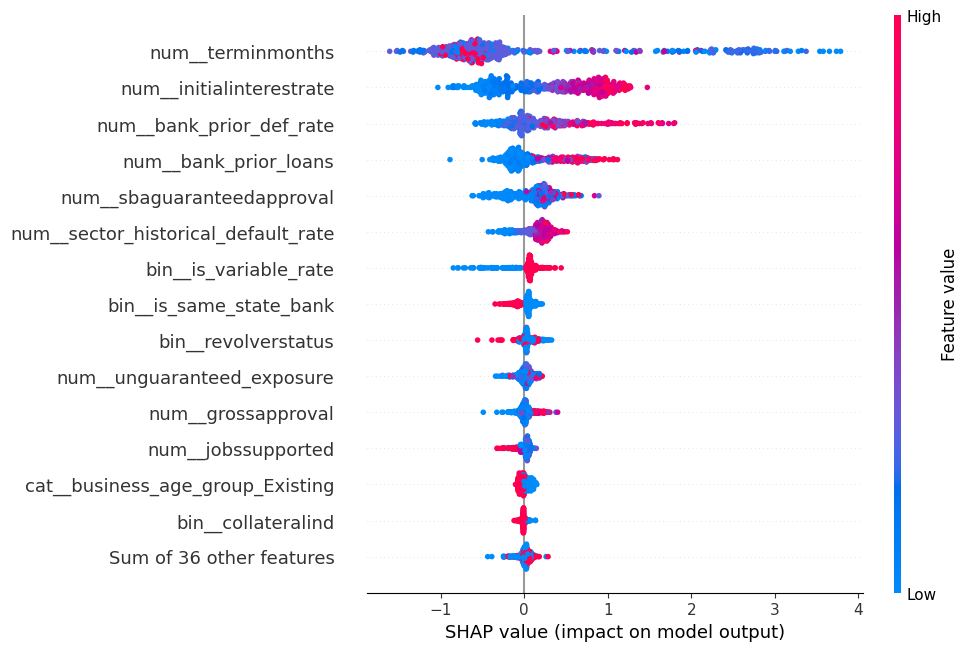

In [18]:
shap.plots.beeswarm(shap_values, max_display=15)

### 8. SHAP Explainability — Global Feature Importance (Beeswarm Plot)

**How to read:** Each dot is one loan. Position on the X-axis shows how much that feature pushed the model toward predicting default (right) or no default (left). Red = high feature value, Blue = low feature value.

**Key Findings:**
1. **Loan Term (`terminmonths`):** The single most important feature. Long-term loans (red dots spreading far right) have dramatically higher default risk — more time = more opportunity for business failure.
2. **Interest Rate (`initialinterestrate`):** High interest rates strongly increase default risk, directly confirming the Federal Reserve rate hike effect we saw in EDA.
3. **Bank Prior Default Rate (`bank_prior_def_rate`):** Our leak-safe engineered feature works — banks with poor historical track records originate significantly riskier loans.
4. **Bank Prior Loans (`bank_prior_loans`):** Inexperienced banks (few prior SBA loans, blue = low) originate riskier loans than experienced SBA lenders.
5. **Variable Rate (`is_variable_rate`):** Variable rate loans carry significantly higher default risk, especially in rising interest rate environments.
6. **Business Age (`business_age_group_Existing`):** Existing businesses (red = 1) strongly reduce default probability — confirming that established businesses are safer borrowers.

In [19]:
test_mask = df['approvalfy'] >= 2021
df_test = df[test_mask].copy()
X_test_full = df_test[all_features]

In [20]:
df_test['PD'] = model.predict_proba(X_test_full)[:, 1]

In [21]:
df_test['LGD'] = (df_test['grossapproval'] - df_test['sbaguaranteedapproval']) / df_test['grossapproval']
df_test['LGD'] = df_test['LGD'].clip(0, 1)

In [22]:
df_test['EAD'] = df_test['grossapproval']

In [23]:
df_test['expected_loss'] = df_test['PD'] * df_test['LGD'] * df_test['EAD']

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [24]:
print(f"Average Predicted Default Probability: {df_test['PD'].mean():.2%}")
print(f"Average LGD (bank's exposure): {df_test['LGD'].mean():.2%}")
print(f"Total Portfolio Expected Loss: ${df_test['expected_loss'].sum():,.0f}")
print(f"Average Expected Loss per Loan: ${df_test['expected_loss'].mean():,.0f}")

Average Predicted Default Probability: 35.95%
Average LGD (bank's exposure): 28.99%
Total Portfolio Expected Loss: $2,237,993,903
Average Expected Loss per Loan: $38,123


### 9. Expected Loss Engine (EL = PD × LGD × EAD)
Using the Basel II/III Expected Loss framework on our post-2021 test portfolio:

| Metric | Value |
|---|---|
| Average Predicted Default Probability (PD) | 35.95% |
| Average Loss Given Default (LGD) | 28.99% |
| Average Expected Loss per Loan (EL) | $38,123 |
| **Total Portfolio Expected Loss** | **$2.24 Billion** |

**Note on Calibration:** The average PD (35.95%) is higher than the actual observed default rate (15.89%) in the test set. This is a known side effect of using `class_weight='balanced'`, which shifts probability outputs upward to maximize recall of the minority class. The model's *ranking* of risky loans is accurate (ROC-AUC = 0.75), but for production use, **Platt Scaling** or **Isotonic Regression** should be applied to calibrate the raw probability outputs.

In [25]:
def assign_risk_tier(pd_score):
    if pd_score < 0.10:
        return '🟢 Tier 1 — Auto Approve'
    elif pd_score < 0.25:
        return '🟡 Tier 2 — Manual Review'
    elif pd_score < 0.40:
        return '🟠 Tier 3 — Senior Review'
    else:
        return '🔴 Tier 4 — Recommend Denial'

In [26]:
df_test['risk_tier'] = df_test['PD'].apply(assign_risk_tier)

In [28]:
print(df_test['risk_tier'].value_counts())

risk_tier
🔴 Tier 4 — Recommend Denial    20020
🟡 Tier 2 — Manual Review       15832
🟢 Tier 1 — Auto Approve        12311
🟠 Tier 3 — Senior Review       10542
Name: count, dtype: int64


In [29]:
print(df_test.groupby('risk_tier')['target'].mean().sort_values(ascending=False))

risk_tier
🔴 Tier 4 — Recommend Denial    0.304695
🟠 Tier 3 — Senior Review       0.137735
🟡 Tier 2 — Manual Review       0.083060
🟢 Tier 1 — Auto Approve        0.037609
Name: target, dtype: float64


### 10. Risk Tier Validation
The model assigns each loan to one of 4 actionable risk tiers based on its predicted PD.

| Tier | Action | Count | Actual Default Rate |
|---|---|---|---|
| 🔴 Tier 4 | Recommend Denial | 20,020 | 30.47% |
| 🟠 Tier 3 | Senior Review | 10,542 | 13.77% |
| 🟡 Tier 2 | Manual Review | 15,832 | 8.31% |
| 🟢 Tier 1 | Auto Approve | 12,311 | 3.76% |

**Result:** The tiers are perfectly monotonically ordered by actual default rate. Tier 4 loans default at 8x the rate of Tier 1 loans, validating the model's ability to meaningfully discriminate credit risk.